In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:/Users/mutch_lf652j0/Customer Churn/data/train.csv')

In [4]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [6]:
df["SeniorCitizen"].nunique()

2

In [17]:
total_old_people_pct = (df["SeniorCitizen"] == 1).sum()/df.shape[0]*100
total_old_people_pct

np.float64(11.41024648515468)

In [7]:
unique_ml = df["MultipleLines"].unique()
print(unique_ml)

['No' 'Yes' 'No phone service']


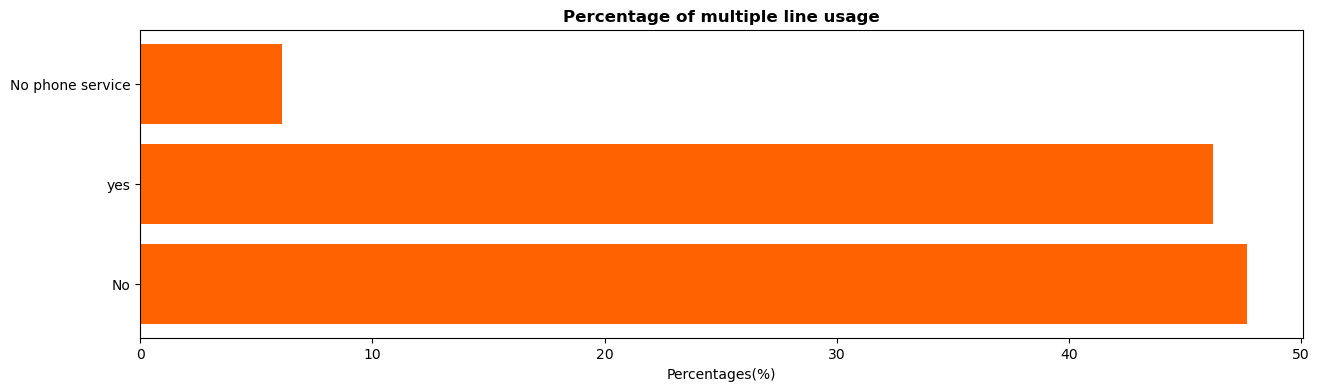

In [14]:
nps_sum = (df['MultipleLines'] == 'No phone service').sum()/df.shape[0] *100
n_sum = (df['MultipleLines'] == 'No').sum()/df.shape[0] *100
y_sum = (df['MultipleLines'] == 'Yes').sum()/df.shape[0] *100

#plot barh for multipleline service

labels = ['No','yes','No phone service']
values = [n_sum, y_sum, nps_sum]

fig, ax = plt.subplots(figsize=(15,4))
ax.barh(labels, values, color = '#ff6200')

plt.title('Percentage of multiple line usage', fontweight = 'bold')
plt.xlabel('Percentages(%)')
plt.show()



In [13]:
nps_sum = (df['MultipleLines'] == 'No phone service').sum()/df.shape[0] *100
nps_sum

np.float64(6.109284173182496)

In [19]:
tenure = df["tenure"]

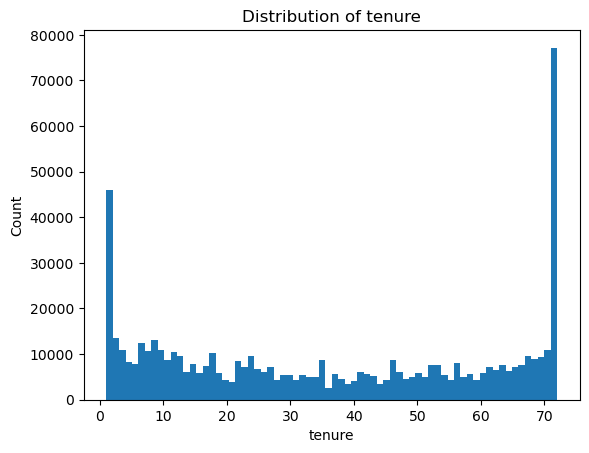

In [26]:
plt.hist(tenure, bins = 70)
plt.xlabel("tenure")
plt.ylabel("Count")
plt.title("Distribution of tenure")
plt.show()
           

In [27]:
#Observable outliers are 2 years and 73

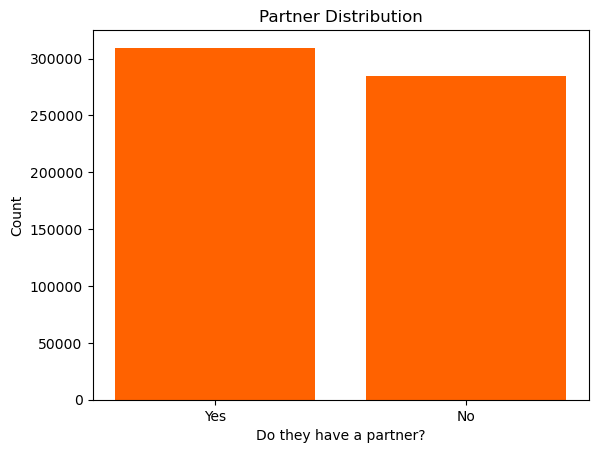

In [35]:
partner_counts = df["Partner"].value_counts()

plt.bar(partner_counts.index, partner_counts.values, color='#ff6200')
plt.xlabel("Do they have a partner?")
plt.ylabel("Count")
plt.title("Partner Distribution")
plt.show()

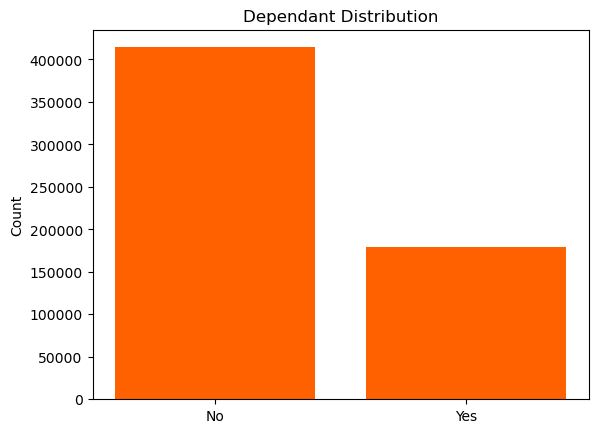

In [45]:
dependents_counts = df["Dependents"].value_counts()

plt.bar(dependents_counts.index, dependents_counts.values, color='#ff6100')  
plt.ylabel("Count")
plt.title("Dependant Distribution")
plt.show()

Text(0.5, 1.0, 'Distribution of Phone Service')

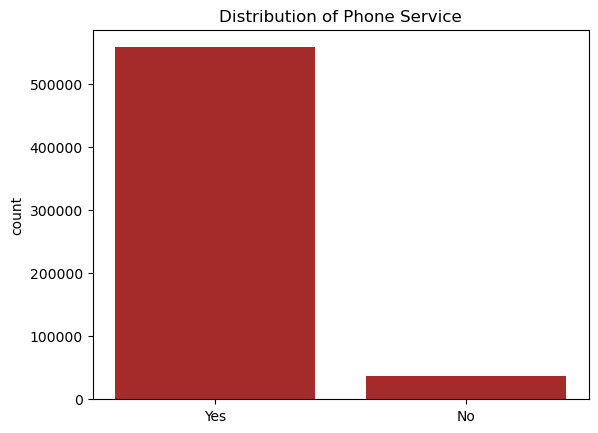

In [48]:
phone_service_count = df["PhoneService"].value_counts()

plt.bar(phone_service_count.index, phone_service_count.values, color = 'brown'
       )
plt.ylabel("count")
plt.title("Distribution of Phone Service")

In [49]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

Text(0.5, 1.0, 'Distribution of Internet Service')

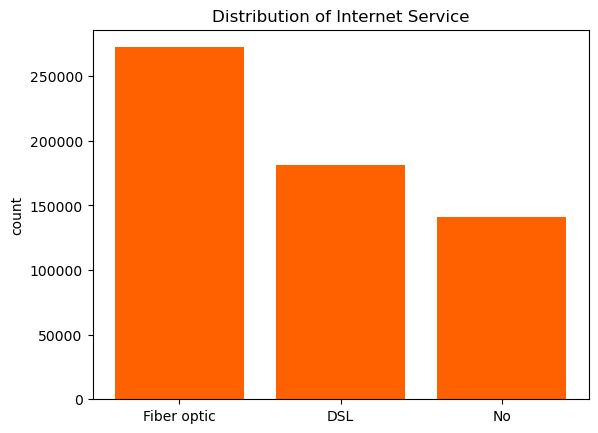

In [50]:
internet_service = df["InternetService"].value_counts()

plt.bar(internet_service.index, internet_service.values, color = '#ff6100')
plt.ylabel("count")
plt.title("Distribution of Internet Service")

In [53]:
contract_type = df["Contract"].unique()
contract_type

array(['One year', 'Two year', 'Month-to-month'], dtype=object)

In [61]:
categorical_columns = df.columns[df.dtypes == "object"]
categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [67]:
"""lets see if there is any relationship between all our columns 
I will first convert categorical columns to numerical columns, then do a correlation matrix. """

categories_convert = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']

for columns in categories_convert:
    df[columns] = df[columns].astype("category").cat.codes

correlation_matrix = df.corr(method = 'spearman')



ValueError: could not convert string to float: 'No'